# 3. Housing Units

In [2]:
%run 00_shared.py

## Raw peek

In [3]:
xl_housing = pd.ExcelFile(f"{DATA_RAW}/Housing Units_2020_0.xlsx")
print("Sheets:", xl_housing.sheet_names)

Sheets: ['Query_Housing Units']


In [4]:
housing = xl_housing.parse(xl_housing.sheet_names[0], header=1)
print(f"Shape: {housing.shape}")
housing.head(10)

Shape: (547, 4)


,Geography,Total:,Occupied,Vacant
0,Maine,739072,582437,156635
1,Androscoggin County,49837,45393,4444
2,Aroostook County,38303,29784,8519
3,Cumberland County,149452,128100,21352
4,Franklin County,20856,12842,8014
5,Hancock County,40133,24948,15185
6,Kennebec County,62607,53223,9384
7,Knox County,24255,17883,6372
8,Lincoln County,23608,15803,7805
9,Oxford County,36130,24712,11418


In [5]:
print(housing.dtypes)
print("\nNulls per column:")
print(housing.isnull().sum())

Geography    object
Total:        int64
Occupied      int64
Vacant        int64
dtype: object

Nulls per column:
Geography    0
Total:       0
Occupied     0
Vacant       0
dtype: int64


In [14]:
housing.describe()

,Total,Occupied,Vacant
count,547.0,547.0,547.0
mean,"4,053.4","3,194.4",859.1
std,"33,062.1","26,186.4","6,938.1"
min,0.0,0.0,0.0
25%,315.0,170.5,77.0
50%,728.0,502.0,190.0
75%,"1,676.0","1,272.5",384.5
max,"739,072.0","582,437.0","156,635.0"


In [7]:
if len(xl_housing.sheet_names) > 1:
    for sheet in xl_housing.sheet_names[1:]:
        df = xl_housing.parse(sheet)
        print(f"\n--- Sheet: {sheet} | Shape: {df.shape} ---")
        display(df.head(5))

## 3a. Clean Housing Data

In [8]:
raw_h = xl_housing.parse("Query_Housing Units")

# Row 0 holds the real column headers; data starts at row 1
raw_h.columns = ["Geography", "Total", "Occupied", "Vacant"]
housing = raw_h.iloc[1:].copy().reset_index(drop=True)
housing[["Total","Occupied","Vacant"]] = housing[["Total","Occupied","Vacant"]].apply(pd.to_numeric, errors="coerce")

housing_state    = housing[housing["Geography"] == "Maine"].copy()
housing_counties = housing[housing["Geography"].isin(MAINE_COUNTIES)].copy()
housing_munis    = housing[~housing["Geography"].isin(["Maine"] + MAINE_COUNTIES)].copy()

housing_counties["vacancy_rate"]   = housing_counties["Vacant"]   / housing_counties["Total"] * 100
housing_counties["occupancy_rate"] = housing_counties["Occupied"] / housing_counties["Total"] * 100
housing_counties["County_Short"]   = housing_counties["Geography"].str.replace(" County", "", regex=False)

print(f"State rows: {len(housing_state)} | County rows: {len(housing_counties)} | Muni rows: {len(housing_munis)}")
print(f"\nMaine: {housing_state['Total'].values[0]:,} total units | "
      f"{housing_state['Occupied'].values[0]:,} occupied | "
      f"{housing_state['Vacant'].values[0]:,} vacant "
      f"({housing_state['Vacant'].values[0]/housing_state['Total'].values[0]*100:.1f}% vacancy)")

housing_counties.sort_values("vacancy_rate", ascending=False)[
    ["County_Short","Total","Occupied","Vacant","vacancy_rate","occupancy_rate"]
].reset_index(drop=True)

State rows: 1 | County rows: 16 | Muni rows: 530

Maine: 739,072 total units | 582,437 occupied | 156,635 vacant (21.2% vacancy)


,County_Short,Total,Occupied,Vacant,vacancy_rate,occupancy_rate
0,Piscataquis,14577,7615,6962,47.8,52.2
1,Franklin,20856,12842,8014,38.4,61.6
2,Hancock,40133,24948,15185,37.8,62.2
3,Washington,21594,13757,7837,36.3,63.7
4,Lincoln,23608,15803,7805,33.1,66.9
5,Oxford,36130,24712,11418,31.6,68.4
6,Somerset,29785,21924,7861,26.4,73.6
7,Knox,24255,17883,6372,26.3,73.7
8,Aroostook,38303,29784,8519,22.2,77.8
9,Waldo,21921,17143,4778,21.8,78.2


## 3b. Vacancy & Housing Unit Counts by County

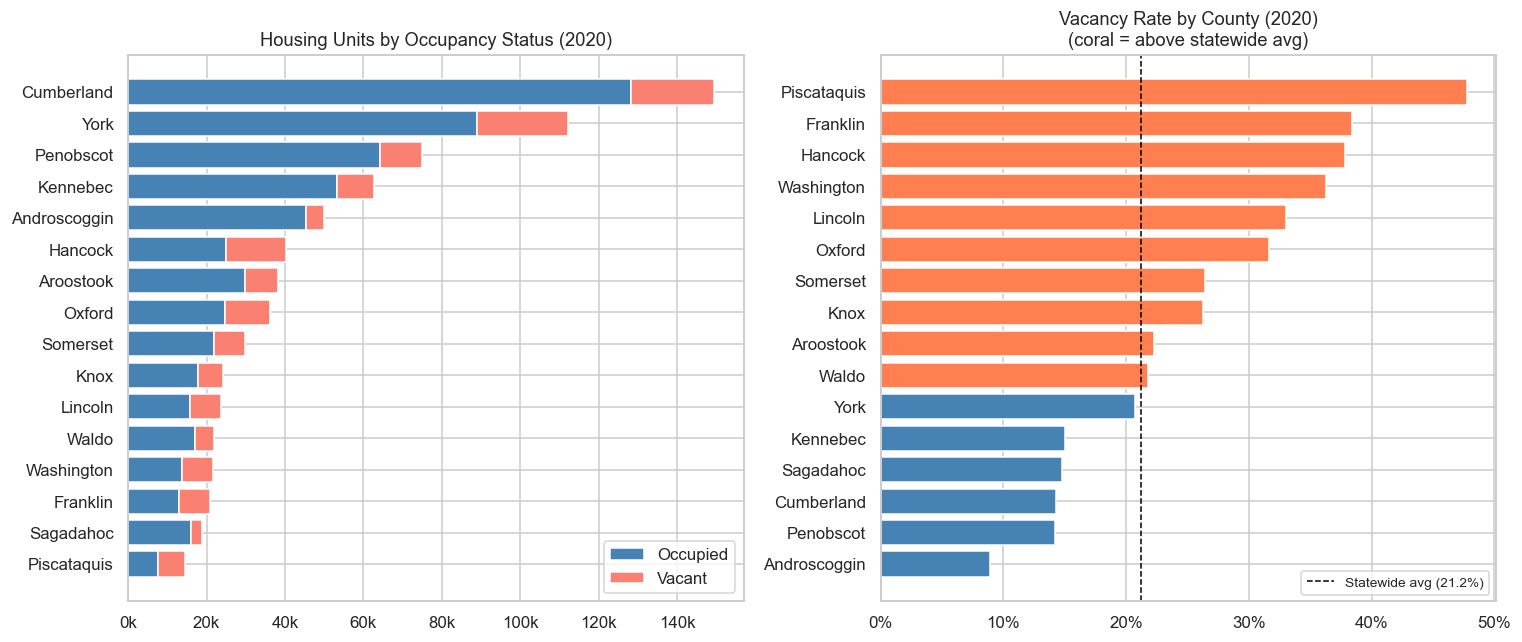

In [9]:
hc = housing_counties.sort_values("Total")
state_vac = housing_state["Vacant"].values[0] / housing_state["Total"].values[0] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(hc["County_Short"], hc["Occupied"], label="Occupied", color="steelblue")
axes[0].barh(hc["County_Short"], hc["Vacant"],   left=hc["Occupied"], label="Vacant", color="salmon")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))
axes[0].set_title("Housing Units by Occupancy Status (2020)")
axes[0].legend()

hc_vac = housing_counties.sort_values("vacancy_rate", ascending=True)
bar_colors = ["coral" if v > state_vac else "steelblue" for v in hc_vac["vacancy_rate"]]
axes[1].barh(hc_vac["County_Short"], hc_vac["vacancy_rate"], color=bar_colors)
axes[1].axvline(state_vac, color="black", linestyle="--", linewidth=1,
                label=f"Statewide avg ({state_vac:.1f}%)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
axes[1].set_title("Vacancy Rate by County (2020)\n(coral = above statewide avg)")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 3c. Municipality Vacancy Distribution

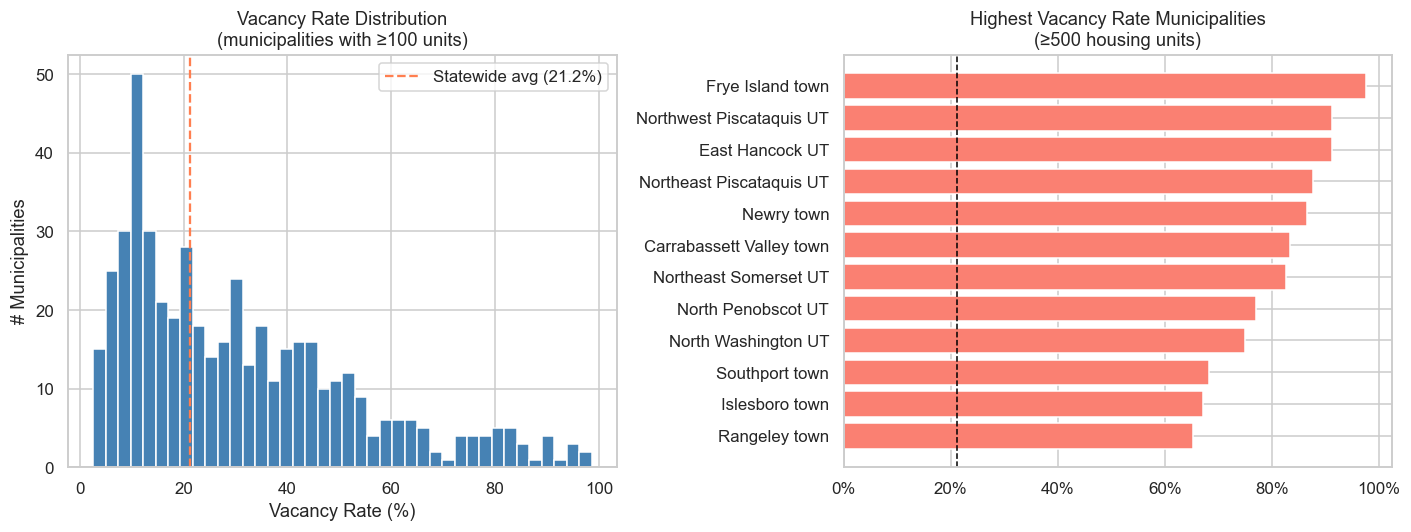


Median muni vacancy rate: 25.2%
Munis with >50% vacancy:  89


In [10]:
munis_h = housing_munis[housing_munis["Total"] >= 100].copy()
munis_h["vacancy_rate"] = munis_h["Vacant"] / munis_h["Total"] * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(munis_h["vacancy_rate"].dropna(), bins=40, color="steelblue", edgecolor="white")
axes[0].axvline(state_vac, color="coral", linestyle="--", label=f"Statewide avg ({state_vac:.1f}%)")
axes[0].set_xlabel("Vacancy Rate (%)")
axes[0].set_ylabel("# Municipalities")
axes[0].set_title("Vacancy Rate Distribution\n(municipalities with \u2265100 units)")
axes[0].legend()

top_vac = munis_h[munis_h["Total"] >= 500].nlargest(12, "vacancy_rate")
axes[1].barh(top_vac["Geography"], top_vac["vacancy_rate"], color="salmon")
axes[1].axvline(state_vac, color="black", linestyle="--", linewidth=1)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
axes[1].set_title("Highest Vacancy Rate Municipalities\n(\u2265500 housing units)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"\nMedian muni vacancy rate: {munis_h['vacancy_rate'].median():.1f}%")
print(f"Munis with >50% vacancy:  {(munis_h['vacancy_rate'] > 50).sum()}")

## Save

In [11]:
pd.to_pickle(
    {
        "housing_state":    housing_state,
        "housing_counties": housing_counties,
        "housing_munis":    housing_munis,
        "state_vac":        state_vac,
    },
    f"{DATA_PROCESSED}/housing.pkl"
)
print("Saved housing.pkl")

Saved housing.pkl
